# Cosmic Microwave Background Angular Power Spectrum Calculation via Spherical Harmonics

## Walkthrough Guide to the CMB by Collin Hitchcock '26

In this notebook we will walk through the computation of the **Cosmic Microwave Background (CMB) angular power spectrum** using **spherical harmonics**. While spherical harmonics is typically covered in Quantum Mechanics, I am going to lay this out so that someone who may be new to both topics can get a base understanding. Hopefully by the end of this notebook, you will get the idea of the following:
* Understand what the CMB is and why it matters
* Understand what spherical harmonics are and how they decompose signals on a sphere
* Utilize a baseline computational approach of the CMB power spectrum
* Implement an optimized version that scales to high angular resolution
* Load in real Planck Satellite data and compare the computational results to the official spectrum
* Visualize the CMB sky and reconstruct it through modes

That being said, there is a lot of complex code that took an entire semester (plus 3 years of coding experience) to understand how to use and implement with the help of Dr. Bellis.

A basic understanding of Python and NumPy are assumed. This also relies on knowledge of complex numbers like the usage of Euler's formula: $e^{i\theta} = \cos\theta + i\sin\theta$. Familiarity with recurrsion methods is also recommended.

I will also leave [my capstone paper](https://drive.google.com/file/d/1kfwjAxgVwxUBjts3wxDf8MYVcnSWM6Zf/view?usp=drive_link) here as a point of reference should you want a deep dive into the development of the pipeline or want to view additional resources under the reference section.

## Overview

| Section | What Will be Covered | Key Takeaway |
|---------|----------------------|-------------|
| 3 | Visualized $Y_\ell^m$ | Higher $\ell$ = finer angular scale |
| 4 | Simple $a_{\ell m}$ approach on fake data | Correct but too slow for real data |
| 5 | Normalized Legendre recurrence + Numba | Stable, fast, scales to large $\ell_{\max}$ |
| 6 | Loaded Planck SMICA map | Real CMB temperature in HEALPix format |
| 7 | Computed $C_\ell$ on real data | Compared to official Planck spectrum |
| 8 | Correlation function + Cosmic Variance | Fundamental statistical limits |
| 9 | Frame by frame CMB animation | Structure builds up with increasing $\ell$ |
| 10 | Acoustic peak fitting | Rough cosmological parameter estimates |

---
# 1. Background
##1.1 The Cosmic Microwave Background

About 380,000 years after the Big Bang, the universe had cooled enough for protons and electrons to combine into neutral hydrogen. Before then, photons would constantly scatter off free electrons meaning the early universe was opaque. Once these atoms began to form, the photons could stream freely in every direction. Today we can still detect these photons as the **Cosmic Microwave Background ([CMB](//www.roe.ac.uk/ifa/postgrad/pedagogy/2006_tojeiro.pdf))**.

When we observe the sky at microwave wavelength, it fills the entire sky with a nearly uniform temperature of **T $\approx$ 2.725 K**. That *nearly* is key because the CMB is not perfectly uniform (anisotropy), as there are tiny temperature fluctuations at the level of $\Delta T / T \sim 10^{-5}$. Its these fluctuations that encode information such as:

* The geometry of the universe (flat, open, or closed)

* The composition of the universe (ordinary matter, dark matter, dark energy)

* The initial conditions seeded during inflation

The main goal of this notebook is to measure those fluctuations by computing the angular power spectrum.

---

##1.2 What are Spherical Harmonics

When working with a flat surface, the natural basis for decomposing a signal is Fourier modes, in other words, sine and cosine waves of different frequencies. When considering the surface of a sphere, the equivalent basis functions are called [spherical harmonics](https://en.wikipedia.org/wiki/Table_of_spherical_harmonics), denoted as $Y_\ell^m (\theta, \phi)$.

Every function on a sphere $f(\theta, \phi)$ can be written as $$f(\theta, \phi) = \sum\limits_{\ell=0}^{\infty} \sum\limits_{m=-\ell}^{\ell}a_{\ell m} Y_\ell^m (\theta, \phi)$$.

The indices are:
* $\ell$ (multipole number): controls the angular scale. Small $\ell$ are large scale structures on the sky. Large $\ell$ represent fine grained features.
* $m$ (azimuthal order): ranges from $-\ell$ to $\ell$. Controls the orientation, not scale.

The spherical harmonics are defined as:
$$ Y_\ell^m (\theta, \phi) = N_{\ell m} P_\ell^{|m|}(\cos\theta) e^{im\phi} $$,

where $P_\ell^m$ are the [associated Legendre polynomials](https://mathworld.wolfram.com/AssociatedLegendrePolynomial.html) (input of $\cos\theta$, not multiplied), and $N_\ell^m$ is a normalization constant.

---
## 1.3 The $a_{\ell m}$ Expansion Coefficients

The CMB temperature map, $\Delta T(\theta, \phi)$, contains expansion coefficients that are obtained by integrating against the spherical harmonics:

$$a_{\ell m} = \int d\Omega \, \Delta T (\theta, \phi) \, Y_\ell^{m*}(\theta, \phi).$$

However, we don't use that integral in practice as we work with the data using discretized pixel measurements. This means we can approximate with a Monte Carlo sum:

$$a_{\ell m} \approx \frac{4\pi}{N} \sum\limits_{i=1}^{N} \Delta T_i \, Y_\ell^{m*}(\theta_i, \phi_i).$$

The $N$ here is now our total number of pixels we are working with. It depends on the resolution of our data, so the higher the resolution, the more points we are going to have. The factor 4π/N comes from N uniformly random points that cover 4π steradians.

---
## 1.4 The Angular Power Spectrum, $C_\ell$

The universe is statistically isotropic, meaning there is no preferred direction. So the variance of $a_{\ell m}$ should not depend on $m$, only $\ell$. Therefore the **[angular power spectrum](https://www.google.com/url?q=https%3A%2F%2Fcmb.wintherscoming.no%2Fpdfs%2FAST5220_cmb_spectrum_2015.pdf)** is defined as:

$$C_\ell = \frac{1}{2\ell + 1} \sum\limits_{m=-\ell}^{\ell} |a_{\ell m}|^2$$

However, this form is not whats typically seen in publications. Instead its the following rescaled form:

$$ D_\ell = \frac{\ell (\ell + 1)}{2\pi} C_\ell \quad [\mu K^2].$$

This flattens the spectrum and allows us to see acoustic peaks as a result of Baryonic Acoustic Oscillations.


---
# 2. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sc
from scipy.special import sph_harm_y, eval_legendre
import time

---
# 3. Visualizing Spherical Harmonics

Before we compute the power spectrum, lets see what spherical harmonics look like.The 3D surfaces below show several $Y_\ell^m$ modes, or rather, where the radius at each direction $(\theta, \phi)$ is proportional to $|Y_\ell^m|$, and the color encodes the sign of the real part.

* $\ell$ = 0: Uniform sphere (monopole), the mean temperature
* $\ell$ = 1: dipole (two lobes)
* $\ell$ = 2: quadrupole (four lobes)
* Higher $\ell$: increasingly fine angular structure

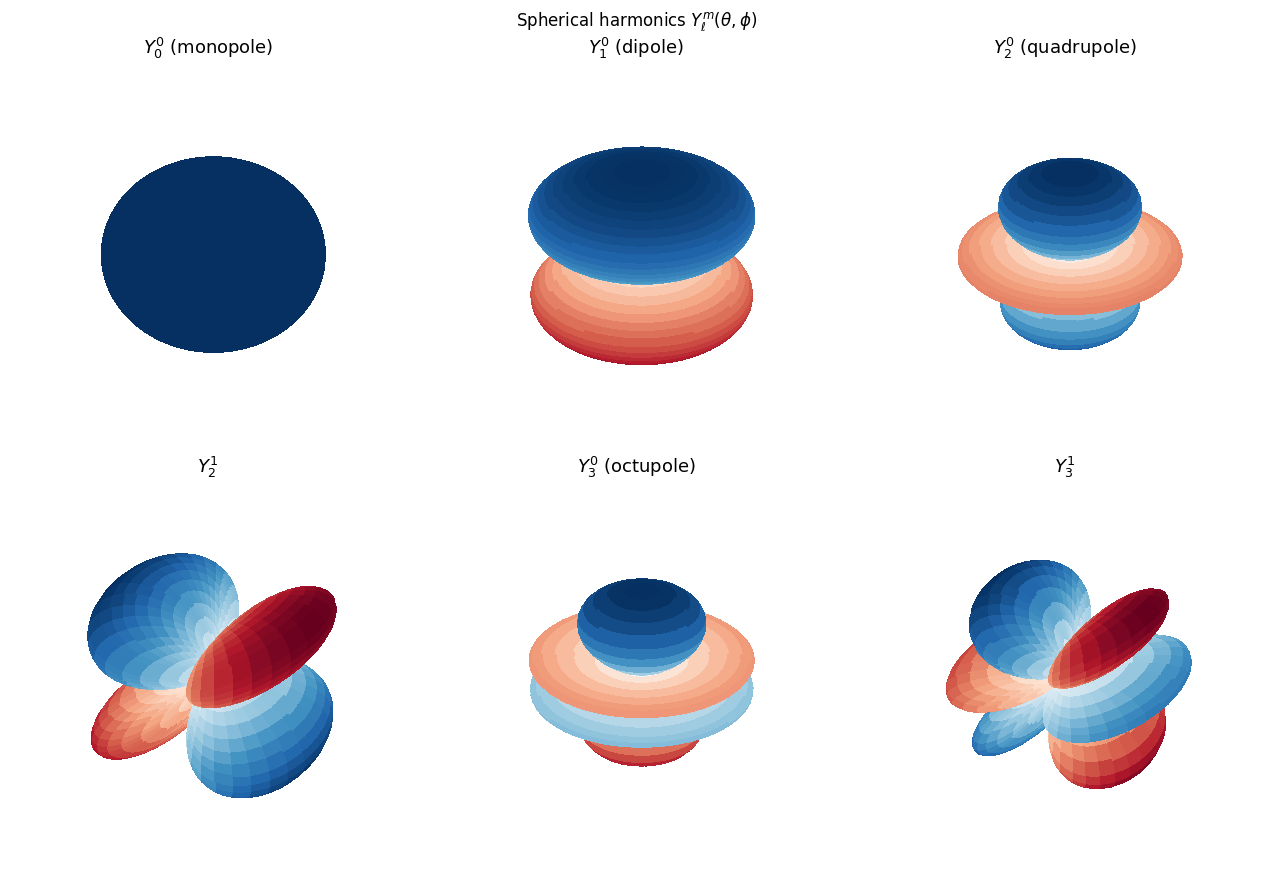

In [ ]:
modes = [(0,0), (1,0), (2,0), (2,1), (3,0), (3,1)]
labels = {
    (0,0): r"$Y_0^0$ (monopole)",
    (1,0): r"$Y_1^0$ (dipole)",
    (2,0): r"$Y_2^0$ (quadrupole)",
    (2,1): r"$Y_2^1$",
    (3,0): r"$Y_3^0$ (octupole)",
    (3,1): r"$Y_3^1$",
}

phi_g, theta_g = np.mgrid[0:np.pi:100j, 0:2*np.pi:100j]
fig = plt.figure(figsize=(13,9))

for i, (l,m) in enumerate(modes):
  ax = fig.add_subplot(2,3,i+1, projection='3d')
  y_lm = sph_harm_y(l, m, phi_g, theta_g)
  r = np.abs(y_lm.real)
  x = r * np.sin(phi_g) * np.cos(theta_g)
  y = r * np.sin(phi_g) * np.sin(theta_g)
  z = r * np.cos(phi_g)
  max_v = np.max(np.abs(y_lm.real))
  norm = y_lm.real / max_v if max_v > 0 else y_lm.real
  ax.plot_surface(x, y, z, facecolors=plt.cm.RdBu((norm+1)/2),
                  rstride=2, cstride=2, antialiased=False, shade=False)
  ax.set_title(labels[(l,m)], fontsize=13)
  ax.set_axis_off()

plt.suptitle(r"Spherical harmonics $Y_\ell^m (\theta, \phi)$")
plt.tight_layout()

---
# 4. Implementation on Fake Data

We'll start with a fake dataset using random points on the sphere with small random temperature fluctuations. This lets us verify our pipeline without worrying about loading in data.

## 4.1 Generating a Fake Sky

In [ ]:
np.random.seed(42)
npts = 100_000

theta_fake = np.pi * np.random.random(npts) # polar angle [0, pi]
phi_fake = 2*np.pi * np.random.random(npts) # azimuthal angle [0, 2pi]

# The following will create tiny random fluctuations
# Simulates CMB to a similar scale
max_fluc = 0.001
dT_fake = 2 * max_fluc * np.random.random(npts) - max_fluc

print(f"Number of points: {npts:,}")
print(f"dT range: [{dT_fake.min():.5f}, {dT_fake.max():.5f}]")

Number of points: 100,000
dT range: [-0.00100, 0.00100]


## 4.2 Computing $a_{\ell m}$ and $C_\ell$

The most straightforward approach calls `scipy.special.sph_harm_y` for every $(\ell, m)$ pair at every point.

This way is very easy to read and verify, but is extremely slow, requiring $\sim N \cdot \ell_{max}^2$ library calls.

In [ ]:
l_max = 10

# Initializing a_lm dictionary for all (l, m) pairs
a_lm_fake = {(l,m): 0.0 + 0.0j
        for l in range(l_max+1) for m in range(-l, l+1)}

total_start = time.time()

for i in range(npts):
  th, ph, Ti = theta_fake[i], phi_fake[i], dT_fake[i]
  for l in range(l_max+1):
    for m in range(-l, l+1):
      # sph_harm_y(l, m, theta, phi) returns Y_lm
      # We take its complex conjugate as seen in the integral
      a_lm_fake[(l, m)] += Ti * np.conj(sph_harm_y(l, m, th, ph))

# Monte Carlo normalization: (4*pi / N) approximates the solid angle integral
norm_const = 4* np.pi / npts
for key in a_lm_fake:
  a_lm_fake[key] *= norm_const

# Power spectrum: average |a_lm|^2 over all m at each l
C_l_fake = {
    l: sum(np.abs(a_lm_fake[(l, m)])**2 for m in range(-l, l+1)) / (2*l+1)
    for l in range(l_max+1)
}

print(f'Elapsed: {time.time() - total_start:.2f} seconds')
print()
for l, cl in C_l_fake.items():
  print(f" l={l:>3d}   C_l = {cl:.4e}")

Elapsed: 82.22 seconds

 l=  0   C_l = 1.9588e-11
 l=  1   C_l = 1.3385e-10
 l=  2   C_l = 6.0870e-11
 l=  3   C_l = 5.3737e-11
 l=  4   C_l = 1.3098e-11
 l=  5   C_l = 2.9124e-11
 l=  6   C_l = 5.9945e-11
 l=  7   C_l = 3.2167e-11
 l=  8   C_l = 6.5841e-11
 l=  9   C_l = 3.1401e-11
 l= 10   C_l = 4.2905e-11


## 4.3 Plotting $C_\ell$

For a purely random (white noise) temperature field, we would expect all $C_\ell$ to be roughly equal, so no preferred angular scale, therefore the plot below *should* appear flat.

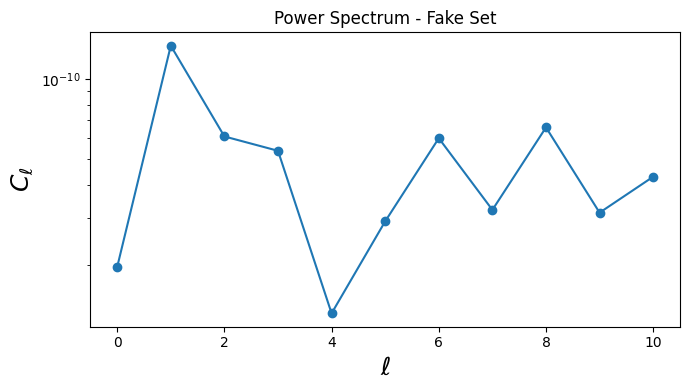

In [ ]:
items = np.array(list(C_l_fake.items()))
ells_n, cl_n = items[:,0], items[:,1]

plt.figure(figsize=(7,4))
plt.plot(ells_n, cl_n, 'o-')
plt.xlabel(r"$\ell$", fontsize=18)
plt.ylabel(r"$C_\ell$", fontsize=18)
plt.title("Power Spectrum - Fake Set")
plt.yscale('log')
plt.tight_layout()

---
# 5. Optimized Implementation

The above method is a bit naive, though correct, but will never finish on real CMB data which consists of $\sim 50$ million pixels, $\ell_{max}\approx 2500$. Therefore we need a smarter approach.

## 5.1 Strategy
The key insight is that $Y_\ell^m$ factors as:
$$ Y_\ell^m (\theta, \phi) = N_{\ell m} \, P_\ell ^{|m|} (\cos\theta) \, e^{im\phi}$$

This means we can:
1. Pre-compute normalization constants, $N_{\ell m}$ once as they dont depend on the data itself.
2. Pre-compute complex exponentials, $e^{im\phi}$ for all m using a cumulative product.
3. Use recurrence relations for the Legendre polynomials instead of calling a library function each time.

## 5.2 Stable Normalized Legendre Recurrence
Rather than computing $P_\ell^m$ and multiplying $N_{\ell m}$ afterward, we can just absorb the normalization *right into* the recurrence. Define $\tilde{P}_\ell^m = N_{\ell m} P_\ell^{|m|}$.

**Sectoral seed** (diagonal $\ell = m$):

$$\tilde{P}_0^0 = \frac{1}{\sqrt{4\pi}}, \qquad \tilde{P}_m^m = -\sqrt{\frac{2m+1}{2m}}\sin\theta \; \tilde{P}_{m-1}^{m-1}$$

**Sub-diagonal seed** ($\ell = m+1$):

$$\tilde{P}_{m+1}^m = \sqrt{2m+3}\cos\theta \; \tilde{P}_m^m$$

**$\ell$ recurrence** (step $\ell$ for fixed $m$):

$$\tilde{P}_\ell^m = \alpha_{\ell m}\cos\theta \; \tilde{P}_{\ell-1}^m - \beta_{\ell m} \; \tilde{P}_{\ell - 2}^m$$

$$\alpha_{\ell m} = \sqrt{\frac{(2\ell+1)(2\ell-1)}{(\ell+m)(\ell-m)}}, \qquad
\beta_{\ell m}  = \sqrt{\frac{(2\ell+1)(\ell+m-1)(\ell-m-1)}{(2\ell-3)(\ell+m)(\ell-m)}}$$

These coefficients remain $O(1)$ (order 1), keeping numerical values stable throughout the recursion.

## 5.3 Precomputing the Recurrence Coefficients

In [ ]:
def calc_rec_coeffs(l_max):
  """
  Precomputes alpha and beta for the stable normalized Legendre recurrence.

  Used in: P_tilde[l,m] = alpha[l,m]*cos(theta)*P_tilde[l-1,m] - beta[l,m]*P_tilde[l-2,m]

  Valid for l >= 2, 0 <= m < l.
  """
  alpha = np.zeros((l_max+1, l_max+1))
  beta = np.zeros((l_max+1, l_max+1))
  for l in range(2, l_max+1):
    for m in range(l):
      lpm = l + m
      lmm = l - m
      alpha[l,m] = np.sqrt((2*l+1) * (2*l-1) / (lpm * lmm))
      beta[l,m] = np.sqrt((2*l+1) * (lpm-1) * (lmm-1) / ((2*l-3) * lpm * lmm))
  return alpha, beta

## 5.4 Full Optimized Pipeline

In [ ]:
def compute_power_spectrum(theta, phi, dT, l_max):
  """
  Computes CMB angular power spectrum C_l from sky pixels

  PARAMETERS
  ----------
  theta : array  polar angles (radians, 0...pi)
  phi   : array  azimuthal angles (radians, 0...2pi)
  dT    : array  temperature fluctuations
  l_max : int    maximum multipole

  RETURNS
  -------
  C_l   : dict   l -> C_l value
  a_lm  : array shape (l_max+1, 2*l_max+1), complex
          a_lm[l, l_max+m] stores the coefficient a_{l, m}
  """

  npts  = len(theta)
  alpha, beta = calc_rec_coeffs(l_max)

  x  = np.cos(theta)   # used throughout Legendre recurrences
  st = np.sin(theta)   # used in the sectoral seed

  # Storage: a_lm[l, l_max+m]  (column offset shifts m=0 to the center)
  a_lm = np.zeros((l_max+1, 2*l_max+1), dtype=np.complex128)

  # ── m = 0 column ─────────────────────────────────────────────────────────
  # Seeds (already normalized):
  P_p2 = np.full(npts, 1.0 / np.sqrt(4.0*np.pi))   # P̃_0^0
  P_p1 = np.sqrt(3.0 / (4.0*np.pi)) * x             # P̃_1^0

  a_lm[0, l_max] += np.sum(dT * P_p2)
  a_lm[1, l_max] += np.sum(dT * P_p1)

  for l in range(2, l_max+1):
      P_curr = alpha[l,0]*x*P_p1 - beta[l,0]*P_p2
      a_lm[l, l_max] += np.sum(dT * P_curr)
      P_p2 = P_p1
      P_p1 = P_curr

  # ── m >= 1 columns ────────────────────────────────────────────────────────
  # Pre-compute e^{i*m*phi} for all m using a cumulative product.
  # e_pos_p[m] = e^{i*m*phi} for all pixels (shape: (l_max+2, npts))
  e_pos_p    = np.ones((l_max+2, npts), dtype=complex)
  e_pos_base = np.exp(1j * phi)
  for m in range(1, l_max+2):
      e_pos_p[m] = e_pos_p[m-1] * e_pos_base

  P_mm_prev = np.full(npts, 1.0 / np.sqrt(4.0*np.pi))  # seeds the diagonal

  for m in range(1, l_max+1):
      # Sectoral seed: P̃_m^m
      P_mm  = -np.sqrt((2*m+1.0)/(2*m)) * st * P_mm_prev
      # Sub-diagonal seed: P̃_{m+1}^m
      P_mp1 = np.sqrt(2*m+3.0) * x * P_mm

      e_negm = e_pos_p[m].conj()   # e^{-i*m*phi}
      e_posm = e_pos_p[m]           # e^{+i*m*phi}
      sign_m = (-1)**m

      # Accumulate a_{l,m} and a_{l,-m} using conjugate symmetry:
      #   conj(Y[l,+m]) = N*P*e^{-i*m*phi}
      #   conj(Y[l,-m]) = (-1)^m * N*P * e^{+i*m*phi}

      # l = m
      a_lm[m,     l_max+m] += np.sum(dT * P_mm * e_negm)
      a_lm[m,     l_max-m] += np.sum(dT * sign_m * P_mm * e_posm)

      # l = m+1
      if m+1 <= l_max:
          a_lm[m+1, l_max+m] += np.sum(dT * P_mp1 * e_negm)
          a_lm[m+1, l_max-m] += np.sum(dT * sign_m * P_mp1 * e_posm)

      # l-recurrence for fixed m
      P_lp2 = P_mm
      P_lp1 = P_mp1
      for l in range(m+2, l_max+1):
          P_lm = alpha[l,m]*x*P_lp1 - beta[l,m]*P_lp2
          a_lm[l, l_max+m] += np.sum(dT * P_lm * e_negm)
          a_lm[l, l_max-m] += np.sum(dT * sign_m * P_lm * e_posm)
          P_lp2 = P_lp1
          P_lp1 = P_lm

      P_mm_prev = P_mm

  # Monte Carlo normalization
  a_lm *= (4.0 * np.pi / npts)

  C_l = {
      l: sum(np.abs(a_lm[l, l_max+m])**2 for m in range(-l, l+1)) / (2*l+1)
      for l in range(l_max+1)
  }

  return C_l, a_lm

## 5.5 Verify against Previous Result

In [ ]:
l_max = 10
start_time = time.time()
C_l_opt, a_lm_opt = compute_power_spectrum(theta_fake, phi_fake, dT_fake, l_max)

print(f"Elapsed: {time.time() - start_time:.3f} seconds.")
print()

print(f"{'l':>4}    {'Previous':>12}    {'Optimized':>12}    {'Ratio':>8}")
print("-" * 48)

for l in range(l_max+1):
  cn, co = C_l_fake[l], C_l_opt[l]
  print(f"{l:>4}    {cn:>12.4e}    {co:>12.4e}    {co/cn:>8.5f}" if cn else f"{l:>4}    {cn:>12.4e}    {co:>12.4e}    {'nan':>8}")

Elapsed: 0.064 seconds.

   l        Previous       Optimized       Ratio
------------------------------------------------
   0      1.9588e-11      1.9588e-11     1.00000
   1      1.3385e-10      1.3385e-10     1.00000
   2      6.0870e-11      6.0870e-11     1.00000
   3      5.3737e-11      5.3737e-11     1.00000
   4      1.3098e-11      1.3098e-11     1.00000
   5      2.9124e-11      2.9124e-11     1.00000
   6      5.9945e-11      5.9945e-11     1.00000
   7      3.2167e-11      3.2167e-11     1.00000
   8      6.5841e-11      6.5841e-11     1.00000
   9      3.1401e-11      3.1401e-11     1.00000
  10      4.2905e-11      4.2905e-11     1.00000


Both methods agree (or at least should agree) to several decimal places. The optimized version is already faster, making it essential for real data. Though theres another step we can take to go even further beyond!

## 5.6 Numba JIT Acceleration
For the highest performance we use Numba, which compiles the inner loops to machine code. Numba works well with NumPy arrays but not with Python dictionaries, so we store $a_{\ell m}$ as a 2D array, indexed by `[l, l_max+m]`.

In [ ]:
import numba

@numba.njit
def comp_alm_jit(x, st, phi, dt, alpha, beta, l_max, npts):
    """
    Numba compiled core loop

    a_lm[l, l_max+m] stores a_{l, m}
    """
    a_lm = np.zeros((l_max+1, 2*l_max+1), dtype=np.complex128)

    # m = 0
    P_p2 = np.full(npts, 1.0 / np.sqrt(4.0*np.pi))
    P_p1 = np.sqrt(3.0 / (4.0*np.pi)) * x
    for i in range(npts):
        a_lm[0, l_max] += dt[i] * P_p2[i]
        a_lm[1, l_max] += dt[i] * P_p1[i]
    for l in range(2, l_max+1):
        P_c = alpha[l,0]*x*P_p1 - beta[l,0]*P_p2
        for i in range(npts):
            a_lm[l, l_max] += dt[i] * P_c[i]
        P_p2 = P_p1; P_p1 = P_c

    # m >= 1
    P_mm_prev = np.full(npts, 1.0 / np.sqrt(4.0*np.pi))
    for m in range(1, l_max+1):
        P_mm  = -np.sqrt((2*m+1.0)/(2*m)) * st * P_mm_prev
        P_mp1 =  np.sqrt(2*m+3.0) * x * P_mm

        e_negm = np.exp(-1j*m*phi)
        e_posm = np.exp( 1j*m*phi)
        sign_m = (-1)**m

        for i in range(npts):
            p = dt[i]*P_mm[i]
            a_lm[m,     l_max+m] += p * e_negm[i]
            a_lm[m,     l_max-m] += sign_m * p * e_posm[i]

        if m+1 <= l_max:
            for i in range(npts):
                p2 = dt[i]*P_mp1[i]
                a_lm[m+1, l_max+m] += p2 * e_negm[i]
                a_lm[m+1, l_max-m] += sign_m * p2 * e_posm[i]

        P_lp2 = P_mm; P_lp1 = P_mp1
        for l in range(m+2, l_max+1):
            P_lm = alpha[l,m]*x*P_lp1 - beta[l,m]*P_lp2
            for i in range(npts):
                p3 = dt[i]*P_lm[i]
                a_lm[l, l_max+m] += p3 * e_negm[i]
                a_lm[l, l_max-m] += sign_m * p3 * e_posm[i]
            P_lp2 = P_lp1; P_lp1 = P_lm

        P_mm_prev = P_mm
    return a_lm

def compute_power_spectrum_numba(theta, phi, dT, l_max):
  """
  Wrapper around Numba compiled a_lm computation
  """
  npts = len(theta)
  alpha, beta = calc_rec_coeffs(l_max)
  x = np.cos(theta)
  st = np.sin(theta)

  a_lm = comp_alm_jit(x, st, phi, dT, alpha, beta, l_max, npts)
  a_lm *= (4.0*np.pi / npts)

  C_l = {
      l: sum(np.abs(a_lm[l, l_max+m])**2 for m in range(-l, l+1)) / (2*l+1)
      for l in range(l_max+1)
  }

  return C_l, a_lm

In [ ]:
print("Compiling Numba function...")
t0 = time.time()
_ = compute_power_spectrum_numba(theta_fake[:500], phi_fake[:500], dT_fake[:500], l_max=3)
print(f"Compile + run: {time.time() - t0:.1f} seconds.")

print()
print("Running over full scale...")
t0 = time.time()
Cl_jit, alm_jit = compute_power_spectrum_numba(theta_fake, phi_fake, dT_fake, l_max)
print(f"Elapsed (post compilation): {time.time() - t0:.3f} seconds.")

Compiling Numba function...
Compile + run: 2.5 seconds.

Running over full scale...
Elapsed (post compilation): 0.104 seconds.


---
# 6. Real Planck Data
Now lets move on to real observations. The **Planck satellite** (ESA, 2009-2013) measured the CMB temperature across the full sky with extreme precision. We use the publically available Planck 2018 SMICA temperature map.

## 6.1 Mounting Google Drive (for Colab)

The Planck FITS file is ~3 GB, and on Colab it can take a long time to read it in each time. Saving it to your Drive makes it so you wont need to redownload every session (also in case Colab crashes).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Change the path to wherever you plan to store your research for this project
research_dir = "drive/MyDrive/Research"
curr_path = os.getcwd()
path = os.path.join(curr_path, research_dir)

try:
  os.mkdir(path)
  print(f"Directory {research_dir} created successfully")
except OSError as error:
  if error.errno == 17:
    os.chdir(path)
    print(f"Directory '{research_dir}' already exists, changing directory.")
  else:
    print(error)

Mounted at /content/drive
Directory 'drive/MyDrive/Capstone Research' already exists, changing directory.


## 6.2 Download the Planck Map

In [ ]:
from astropy.io import fits
import requests

PLANCK_url = "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/maps/component-maps/cmb/COM_CMB_IQU-smica_2048_R3.00_full.fits"

FITS_path = "COM_CMB_IQU-smica_2048_R3.00_full.fits"


try:
  with fits.open(FITS_path) as hdul:
    hdul.info()
  print("File exists, no download necessary.")

except Exception:
  print("Attempting to download Planck 2018 Data (~3 GB)...")

  response = requests.get(PLANCK_url, stream=True)
  response.raise_for_status()

  with open(FITS_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
      f.write(chunk)
  print("Download complete.")

Filename: COM_CMB_IQU-smica_2048_R3.00_full.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1                1 BinTableHDU     67   50331648R x 10C   [1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   
  2                1 BinTableHDU     18   4097R x 2C   [1E, 1E]   
File exists, no download necessary.


## 6.3 Loading and Visualization

The map uses the HEALPix pixelization, meaning the sphere is divided into equal area pixels labeled by an Nside parameter. Nside=2048 gives the full resolution map (~50 million pixels). Lower Nside values save memory but reduce the maximum $\ell$ you can measure (roughly $\ell_{max} \approx 2 \times \text{Nside}$).

In [ ]:
!pip install healpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 24.2 MB/s eta 0:00:00


In [ ]:
# This starts to use up memory, maybe around 1GB

import healpy as hp

# This can be reduced to 64, 128, 256, etc. Use 2048 for full resolution
NSIDE = 64

# field=0 :: T, field=1 :: Q, field=2 :: U
map_full = hp.read_map(FITS_path, field=0)
map_planck = hp.ud_grade(map_full, nside_out=NSIDE, power=0) * 1e6 # K -> µK
del map_full

npts = hp.nside2npix(NSIDE)
theta, phi = hp.pix2ang(NSIDE, np.arange(npts))
dT = map_planck

print(f"Pixels  : {npts:,}")
print(f"dT std  : {np.std(dT):.2f} µK")

Pixels  : 49,152
dT std  : 77.71 µK


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3708/3453187435.py:3: SyntaxWarning: invalid escape sequence '\m'
  unit='$\mu$K',


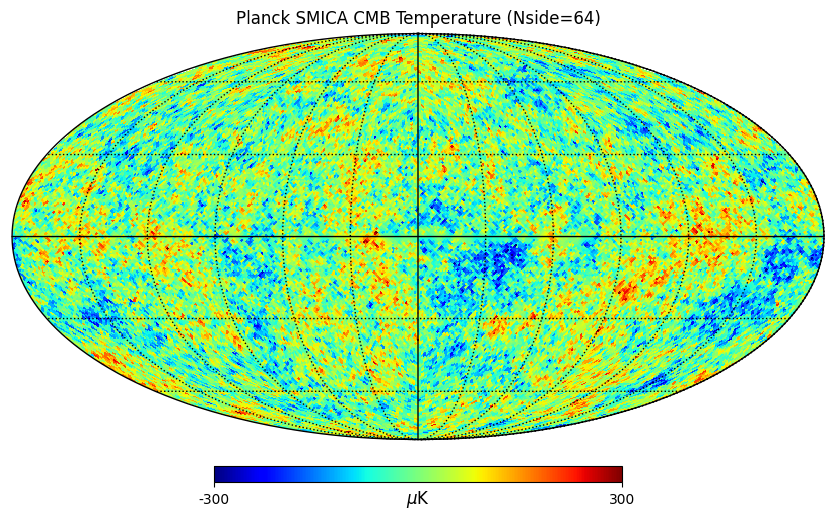

In [ ]:
hp.mollview(dT,
            title=f'Planck SMICA CMB Temperature (Nside={NSIDE})',
            unit='$\mu$K',
            cmap='jet',
            min=-300, max=300)
hp.graticule()

---
# 7. Power Spectrum from Real Planck Data

We can now apply our optimized algorithm to the full Planck pixel data.

> **Memory note:**
Precomputing all $e^{im\phi}$ at once as a 2D array requires $(\ell_{\max}+2) \times N_{\text{pix}}$ complex numbers. At $\ell_{\max}=100$, $N=50\text{M}$ which comes out to ~80 GB. The numba version computes exponentials on the fly to avoid that.

Lets set `l_max` to a small value (perhaps 10) for a quick test, then for real science use 1000+.

In [ ]:
l_max = 10

print(f"Computing power spectrum to l_max={l_max} on {npts:,} pixels...")
t0 = time.time()
Cl_planck, alm_planck = compute_power_spectrum_numba(theta, phi, dT, l_max)
print(f"Elapsed: {time.time()-t0:.1f} seconds.")

Computing power spectrum to l_max=10 on 49,152 pixels...
Elapsed: 1.3 seconds.


## 7.1 Comparing to the Official Planck Spectrum

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3708/3329132635.py:4: SyntaxWarning: invalid escape sequence '\s'
  planck_data = pd.read_csv(planck_url, comment='#', sep='\s+', names = ['ell', 'Dl', 'errlo', 'errhi'])


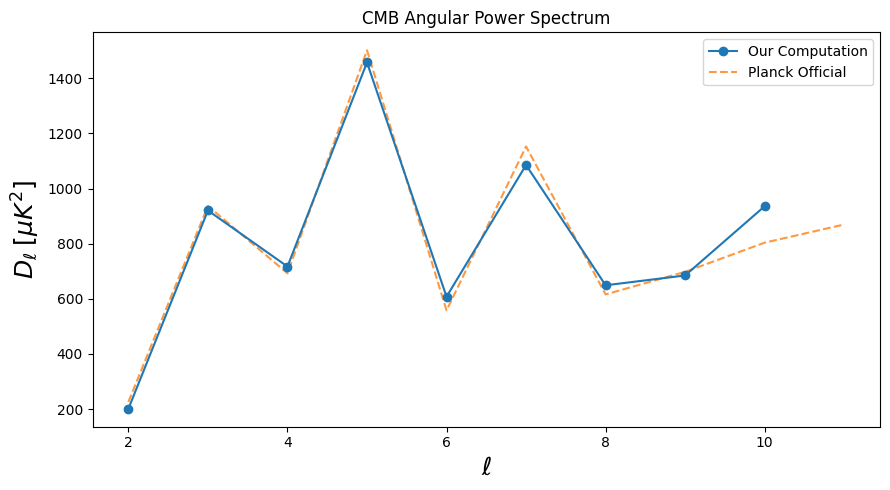

In [ ]:
import pandas as pd

planck_url = "https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/cosmoparams/COM_PowerSpect_CMB-TT-full_R3.01.txt"
planck_data = pd.read_csv(planck_url, comment='#', sep='\s+', names = ['ell', 'Dl', 'errlo', 'errhi'])

# Need to scale our C_l to D_l = l(l+1)/(2*pi)*C_l
items_p = np.array(list(Cl_planck.items()))
ells_p = items_p[:,0]
Cl_p = items_p[:,1]
Dl_p = ells_p * (ells_p + 1) * Cl_p / (2*np.pi)

plt.figure(figsize=(9,5))
plt.plot(ells_p[2:], Dl_p[2:],
         'o-', label='Our Computation', zorder=3)
plt.plot(planck_data['ell'][:l_max], planck_data['Dl'][:l_max],
         '--', alpha=0.8, label='Planck Official')

plt.xlabel(r"$\ell$", fontsize=18)
plt.ylabel(r"$D_\ell \; [\mu K^2]$", fontsize=18)
plt.title("CMB Angular Power Spectrum")
plt.legend()
plt.tight_layout()


## 7.2 Quick Sanity Check by Comparing with HEALPy's `anafast` function

`hp.anafast` is a highly optimized spherical harmonic transform built into HEALPy.

Our result should also match that closely.

In [ ]:
Cl_healpy = hp.anafast(map_planck, lmax=l_max)

print(f"{'l':>4}    {'Our C_l':>14}    {'HEALPy C_l':>14}    {'Ratio':>8}")
print("-"*52)
for l in range(1, min(l_max + 1, 12)):
  co = Cl_planck[l]
  ch = Cl_healpy[l]
  r = co/ch if ch else float('nan')
  print(f"{l:>4}    {co:>14.4e}    {ch:>14.4e}    {r:>8.4f}")

   l           Our C_l        HEALPy C_l       Ratio
----------------------------------------------------
   1        5.1394e-06        6.8672e-06      0.7484
   2        2.1038e+02        2.1039e+02      1.0000
   3        4.8197e+02        4.8196e+02      1.0000
   4        2.2525e+02        2.2526e+02      1.0000
   5        3.0526e+02        3.0526e+02      1.0000
   6        9.0893e+01        9.0893e+01      1.0000
   7        1.2177e+02        1.2177e+02      1.0000
   8        5.6637e+01        5.6637e+01      1.0000
   9        4.7795e+01        4.7794e+01      1.0000
  10        5.3457e+01        5.3455e+01      1.0000


---
# 8. Additional Ways to Analyze

## 8.1 Two-Point Correlation Function $C(\theta)$

If you were to measure the temperature at one point on the CMB sky, how correlated is it with the temperature at another point that is separated by an angle $\theta$?

Imagine you are in some environment that consists of hills and valleys. If you are standing on top of a hill, how likely is it that a point some distance $\theta$ away is also on a hill? This is essentially what a correlation function measures.

Mathematically, its just an average of the product of temperature fluctuations over all pairs of points at that separation:
$$ C(\theta) = \langle\Delta T(\hat{n}_1) \cdot \Delta T(\hat{n}_2)\rangle$$ where $\hat{n}_1 \cdot \hat{n}_2 = \cos\theta$.

* If $C(\theta)$ is large and positive, hot spots tend to be near other hot spots at that scale.
* If $C(\theta)$ is near zero, temperature at that separation are unrelated.

Because the CMB lives on a sphere, its natural to decmpose into spherical harmonics. Each multipole moment corresponds to an angular scale of roughly $\theta \sim 180^\circ / \ell$. The power spectrum tells us how much "power" (variance) exists at each angular scale. The correlation function and power spectrum are what's called a **transform pair**:
$$C(\theta) = \sum\limits_\ell \frac{2\ell + 1}{4\pi} C_\ell \, P_\ell (\cos\theta).$$

Here we are working with just Legendre Polynomials. These carry identical information, just packaged differently, one being in angle space, the other being frequency ($\ell$) space.

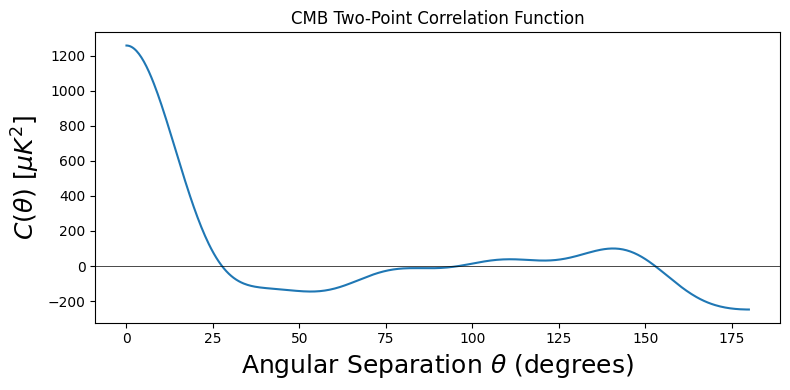

In [ ]:
angles = np.linspace(0, np.pi, 500)
costh = np.cos(angles)
C_th = np.zeros(len(angles))

for l, cl_val in Cl_planck.items():
  if l == 0: continue
  C_th += (2*l + 1) * cl_val * eval_legendre(l, costh)

C_th /= (4*np.pi)

plt.figure(figsize=(8,4))
plt.plot(np.degrees(angles), C_th)
plt.xlabel(r"Angular Separation $\theta$ (degrees)", fontsize=18)
plt.ylabel(r"$C(\theta)$ [$\mu K^2$]", fontsize=18)
plt.title("CMB Two-Point Correlation Function")
plt.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()


## 8.2 Cosmic Variance

No matter how much we might perfect our instruments, there is an irreducible statistical uncertainty called **cosmic variance**. At each $\ell$ we have only $2\ell + 1$ independent $m$ values, so the fractional uncertainty on $C_\ell$ is:
$$\frac{\Delta C_\ell}{C_\ell} = \sqrt{\frac{2}{2\ell + 1}}$$

Low $\ell$ modes have large cosmic variance, meanwhile high $\ell$ modes are well determined.

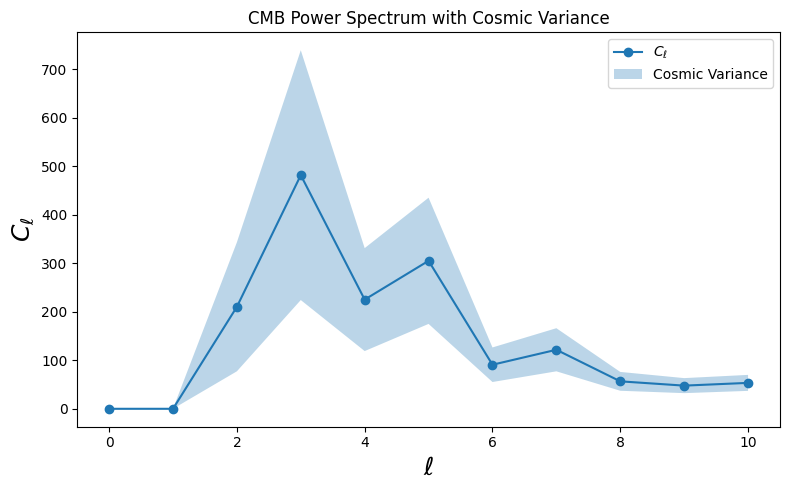

In [ ]:
# Cosmic Variance
cv_upp = Cl_p * (1 + np.sqrt(2 / (2*ells_p + 1)))
cv_low = Cl_p * (1 - np.sqrt(2 / (2*ells_p + 1)))

plt.figure(figsize=(8,5))
plt.plot(ells_p, Cl_p, 'o-', label=r"$C_\ell$")
plt.fill_between(ells_p, cv_low, cv_upp, alpha=0.3, label="Cosmic Variance")
plt.xlabel(r"$\ell$", fontsize=18)
plt.ylabel(r"$C_\ell$", fontsize=18)
plt.title("CMB Power Spectrum with Cosmic Variance")
plt.legend()
plt.tight_layout()

# 9. CMB Reconstruction Animation

This section will help you generate an animation showing how the CMB sky map builds up as we include more and more multipoles $\ell$. Each frame adds higher $\ell$ modes, gradually revealing finer angular structure.

If you haven't ran the computation of $a_{\ell m}$'s over the full Planck resolution (2048), you can ask Dr. Bellis for the GPU calculated $a_{\ell m}$ file.

In [ ]:
def alm2hpy(a_lm, l_max, l_cur):
  """
  Converts our a_lm[l, l_max+m] array to HEALPy's compact format.

  HEALPy stores only m >= 0, using the symmetry Y_l^m = (-1)^m * conj(Y_l^m).
  hp.Alm.getidx(l_max, l, m) returns the 1D index for a given (l, m).
  """
  alm_hp = np.zeros(hp.Alm.getsize(l_cur), dtype=np.complex128)
  for l in range(l_cur+1):
    for m in range(l+1):
      idx = hp.Alm.getidx(l_cur, l, m)
      alm_hp[idx] = a_lm[l, l_max + m]
  return alm_hp

In [ ]:
alm_file = "GPU_alm_resolution_2048_lmax_2500.npy"
if os.path.exists(alm_file):
  alm_gpu = np.load(alm_file)
  lmax_gpu = len(alm_gpu) - 1
  print(f"Loaded {alm_file} (l_max={lmax_gpu})")
else:
  print(f"No {alm_file} file found.")
  alm_gpu = None

Loaded GPU_alm_resolution_2048_lmax_2500.npy (l_max=2500)


In [ ]:
if alm_gpu is not None:
  import subprocess
  os.makedirs('cmb_frames', exist_ok=True)

  l_steps = np.linspace(1, min(2050, lmax_gpu), 100, dtype=int)
  ells_planck = planck_data['ell'].values
  Dl_planck = planck_data['Dl'].values
  C_gpu = np.array([sum(np.abs(alm_gpu[l])**2)/(2*l+1) for l in range(len(alm_gpu))])
  ells_gpu = np.arange(len(C_gpu))
  D_gpu = ells_gpu*(ells_gpu + 1) / (2*np.pi) * C_gpu


  for i, l_curr in enumerate(l_steps):
    print(f"Frame {i+1}/{len(l_steps)}: l_max={l_curr}")

    #############
    ## Sky Map ##
    #############
    alm_hp = alm2hpy(alm_gpu, lmax_gpu, l_curr)
    sky_map = hp.alm2map(alm_hp, nside=2048, verbose=False)

    fig = plt.figure(figsize=(18,6))
    hp.mollview(sky_map, fig=fig.number, title=f"CMB Reconstruction - $\\ell_{{max}}$ = {l_curr}", unit=r"$\mu K$",
              cmap="jet",
                sub=(1,2,1), min=-300, max=300)
    hp.graticule()

    ####################
    ## Power Spectrum ##
    ####################
    ax = fig.add_subplot(1,2,2)
    ax.plot(ells_planck, Dl_planck, color='gray', alpha=0.4, lw=1, label="Planck Official")
    ax.plot(ells_gpu[2:l_curr+1], D_gpu[2:l_curr+1], color='steelblue', lw=1.5, label='Computation')
    ax.axvline(l_curr, color='red', linestyle='--', alpha=0.7, lw=1)

    ax.set_xlim(0,lmax_gpu)
    ax.set_ylim(0,6500)
    ax.set_xlabel(r'$\ell$', fontsize=14)
    ax.set_ylabel(r'$D_\ell \; [\mu K^2]$', fontsize=14)
    ax.set_title('Angular Power Spectrum', fontsize=16)
    ax.legend(fontsize=10)

    plt.savefig(f'frames5/frame_{i:04d}.png', dpi=300, bbox_inches='tight')
    plt.close()

    del sky_map, alm_hp

  print("All frames saved!")

  import subprocess

  result = subprocess.run(
      ['ffmpeg', '-framerate', '4',
      '-i', 'frames5/frame_%04d.png',
      '-c:v', 'libx264', '-profile:v',
      'baseline', '-level', '3.0',
      '-pix_fmt', 'yuv420p', '-vf',
      'pad=ceil(iw/2)*2:ceil(ih/2)*2',
      '-y',
      'cmb_evolution.mp4'],
      capture_output=True, text=True
  )

  print("Video saved: cmb_evolution.mp4" if result.returncode == 0
        else "ffmpeg error: " + result.stderr[-300:])

# 10. Bonus: Estimating Cosmological Parameters from Acoustic Peaks

The CMB power spectrum has a series of acoustic peaks, these are oscillations in $D_\ell$ caused by sound waves in the early universe plasma. The ratios of the first three peak heights give rough estimates of the baryon and dark matter densities.

$$ \frac{P_1}{P_2} \approx 1 + 6\Omega_b h^2 , \quad \frac{P_1}{P_3} \approx \Omega_{DM} h^2$$ where $h = H_0/100$ and $H_0 \approx 67 \, \text{km/s/Mpc}$.

Keep in mind this is a highly simplified estimate compared to a full Markov Chain Monte Carlo cosmological fit. This area is something I have not been able to delve into myself as of writing this, so results are not quite accurate. With a better a_lm calculation, better estimations would be possible.

In [ ]:
from scipy.signal import argrelmax
from scipy.interpolate import UnivariateSpline

if alm_gpu is not None:
  lmax_fit = 2500
  ells_fit = np.arange(2, lmax_fit+1)
  C_fit = np.array([sum(np.abs(alm_gpu[l])**2) / (2*l + 1) for l in range(2, lmax_fit + 1)])
  D_fit = C_fit * ells_fit*(ells_fit + 1) / (2*np.pi)

  spline = UnivariateSpline(ells_fit, D_fit, s=len(ells_fit)*10)
  D_smooth = spline(ells_fit)
  peak_idx = argrelmax(D_smooth, order=50)[0]

  print("Acoustic Peaks found:")
  for k, (pe, pd) in enumerate(zip(ells_fit[peak_idx[:5]], D_smooth[peak_idx[:5]])):
    print(f"Peak {k+1}: ell={pe}    D_l={pd:.1f} µK^2")

  P1, P2, P3 = D_smooth[peak_idx[0]], D_smooth[peak_idx[1]], D_smooth[peak_idx[2]]
  print()

  print(f"Estimated Omega_b * h^2 = {(P1/P2 - 1)/6:.4f} (Planck Official: 0.0224)")
  print(f"Estimated Omega_DM * h^2 = {P1/P3:.4f} (Planck Official: 0.120)")
else:
  print("a_lm file not loaded.")

Acoustic Peaks found:
Peak 1: ell=236    D_l=6225.1 µK^2
Peak 2: ell=522    D_l=2550.5 µK^2
Peak 3: ell=785    D_l=2056.6 µK^2
Peak 4: ell=1103    D_l=838.3 µK^2
Peak 5: ell=1398    D_l=468.8 µK^2

Estimated Omega_b * h^2 = 0.2401 (Planck Official: 0.0224)
Estimated Omega_DM * h^2 = 3.0268 (Planck Official: 0.120)


/tmp/ipykernel_3708/3211797600.py:10: UserWarning: 
A theoretically impossible result was found during the iteration
process for finding a smoothing spline with fp = s: s too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(ells_fit, D_fit, s=len(ells_fit)*10)


---
# Further Reading
* [Planck 2018 Papers](https://www.google.com/url?q=https%3A%2F%2Fwww.cosmos.esa.int%2Fweb%2Fplanck%2Fpublications)
* [HEALPix Documentation](https://www.google.com/url?q=https%3A%2F%2Fhealpy.readthedocs.io)
* [SciPy Spherical Harmonic Function](https://www.google.com/url?q=https%3A%2F%2Fdocs.scipy.org%2Fdoc%2Fscipy%2Freference%2Fgenerated%2Fscipy.special.sph_harm_y.html)

There are also many sources not listed in this notebook that are available under the reference section of my capstone paper.